<table class="table table-bordered">
    <tr>
     <th style="text-align:center;"><h3>IS217 - Clustering</h3><h3>Wine Dataset Case Study</h3></th>
    </tr>
</table>

**About the Data :** <br>
This is a dataset containing chemical properties of different types of wines. The columns contain the quantities of 13 chemical constituents found in wines. More details here - https://archive.ics.uci.edu/ml/datasets/Wine <br>
<br>

**Analytic Questions:**<br>
The following two questions will be investigated:

- Is it possible to discover the cultivar of a wine by analyzing its chemical features?
- What are the chemical features of the natural grouping of wines? 

This notebook covers the following : <br>
1. Reading wines dataset and performing EDA
2. Data Preparation & EDA 
3. K-Means modeling: (a) Determining suitable k using Elbow method; (b) 4. Applying k-means with suitable k
4. Cluster Evaluation and Profiling
5. Variables Weighting 
6. Model comparisons

In [1]:
# Here are some codes to avoid a warning on Windows machines
# The warning is related to "KMeans is known to have a memory leak on Windows with MKL..."

#import os
#os.environ["OMP_NUM_THREADS"] = '1'

# Alternatively, suppress the warnings
#import warnings
#warnings.filterwarnings("ignore")

In [1]:
# import the required libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### 1. Reading the data and basic EDA

The attributes are (dontated by Riccardo Leardi, riclea@anchem.unige.it)
   1. Alcohol
   2. Malic acid - Organic compound in living organisms. It contributes to the sour taste of fruits, and is often used as a food additive. 
   3. Ash - Ash determination is an obligatory analysis for certified wines to be placed on the market. It is defined as all the inorganic matter remaining after igniting the residue left from the evaporation of must or wine
   4. Alcalinity of ash  
   5. Magnesium
   6. Total phenols - Phenols are compounds which are important plant constituents with redox properties responsible for antioxidant activity
   7. Flavanoids  -  Flavonoids are a diverse group of phytonutrients (plant chemicals) found in almost all fruits and vegetables. 
   8. Nonflavanoid phenols
   9. Proanthocyanidins - Proanthocyanidins (PACs) are a class of polyphenols (naturally occurring organic compounds) found in a variety of plants.
   10. Color intensity
   11. Hue 
   12. OD280/OD315 of diluted wines - This is a chemical analysis measurement used to determine the concentration and quality of protein in wine.
   13. Proline - an amino acid in wine   

In [2]:
# Read the data
wines = pd.read_csv('wine.csv')

In [3]:
wines.head()

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


##### Find the number of rows and columns. Check if the data has missing values

In [4]:
# Write your code below
wines.info()

#wines.count() counts number of values in each column, and wines.describe() gives statistical description
#if you wanna find missing values, if it prints zero, there is no null values
# wines.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic.acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Acl                   178 non-null    float64
 4   Mg                    178 non-null    int64  
 5   Phenols               178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid.phenols  178 non-null    float64
 8   Proanth               178 non-null    float64
 9   Color.int             178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD                    178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


##### Print the basic descriptive stats for the data. Round the values to 3 decimal places

In [5]:
# Write your code below
# Round function allows you to round to dp 
round(wines.describe(), 3)
# in this case, all variables are numerical, if the variables were not numerical, it will show NaN

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,13.001,2.336,2.367,19.495,99.742,2.295,2.029,0.362,1.591,5.058,0.957,2.612,746.893
std,0.812,1.117,0.274,3.340,14.282,0.626,0.999,0.124,0.572,2.318,0.229,0.710,314.907
min,11.030,0.740,1.360,10.600,70.000,0.980,0.340,0.130,0.410,1.280,0.480,1.270,278.000
25%,12.362,1.602,2.210,17.200,88.000,1.742,1.205,0.270,1.250,3.220,0.782,1.938,500.500
50%,13.050,1.865,2.360,19.500,98.000,2.355,2.135,0.340,1.555,4.690,0.965,2.780,673.500
75%,13.678,3.082,2.558,21.500,107.000,2.800,2.875,0.438,1.950,6.200,1.120,3.170,985.000
max,14.830,5.800,3.230,30.000,162.000,3.880,5.080,0.660,3.580,13.000,1.710,4.000,1680.000


##### Plot the histograms for wines data

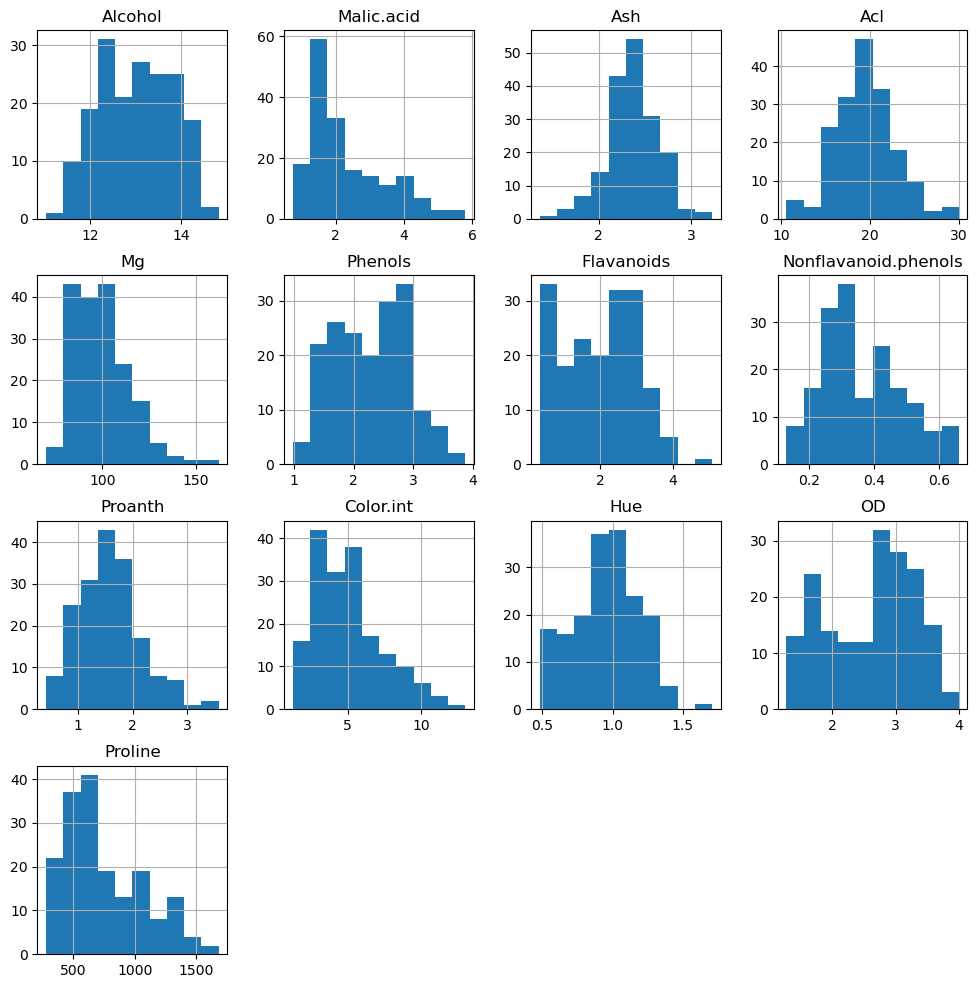

In [8]:
# Some of you need to execute this line of code to have your charts displayed within the notebook
#%matplotlib inline
# wines.hist() works but the graphs are very cramped
wines.hist(figsize = (12,12))
plt.show()

In statistics, skewness is a measure of the asymmetry of the probability distribution of a random variable about its mean. The skewness value can be positive or negative, or even undefined. If skewness = 0, the data are perfectly symmetrical. <br />
A skewness of exactly zero is quite unlikely for real-world data. How do we interpret the skewness number?<br />

- (Bulmer 1979) — a classic — suggests that skewness is <b>less than -1 or greater than 1</b> is considered as skewed.
- More recent literature such as (George & Mallery, 2010) and Hair et al. (2010) suggested that skewness <b>between -2 and +2 </b> are considered acceptable.

References:
- Bulmer, M. G. (1979). Principles of Statistics (Dover). New York: Dover.
- George, D. & Mallery, M. (2010). SPSS for Windows Step by Step: A Simple Guide and Reference, 17.0 update (10a ed.) Boston: Pearson.
- Hair, J., Black, W. C., Babin, B. J. & Anderson, R. E. (2010) Multivariate data analysis (7th ed.). Upper Saddle River, New Jersey: Pearson Educational International. 


In [9]:
# Let's analyse quantitatively the skewness of the variables in the dataset
wines.skew()

Alcohol                -0.051482
Malic.acid              1.039651
Ash                    -0.176699
Acl                     0.213047
Mg                      1.098191
Phenols                 0.086639
Flavanoids              0.025344
Nonflavanoid.phenols    0.450151
Proanth                 0.517137
Color.int               0.868585
Hue                     0.021091
OD                     -0.307285
Proline                 0.767822
dtype: float64

### Think!
Are any variables relatively skewed based on Bulmer's criteria? If so, which ones?

Put your answer below: Malic Acid and Mg

### Summarizing EDA observations

 1) What are your observations from the EDA steps above?<br />
 2) Do we need to prepare the data before applying k-means? E.g., transformation or standardization?<br />

<b>Hint</b> : Look at the mean, std, and histograms across variables. Check for scale differences and skewness.

Put your answer below: </br>
We may want to apply transformation for the 2 variables `Malic acid` and `Mg`

### 2. Data preparation

#### 2.1 Variable Selection

The number of variables in this dataset is not too large. We will skip variable selection for now. 

#### 2.2 Data Transformation

Suppose we decided to transform the  variables `Malic.acid` and `Mg`. We may not always know upfront which transformation is necessary -- it could be a `log` transformation, a `square root` transformation or another type. Often, testing multiple transformations is needed to find the suitable one.<br />
In this notebook, we will try the `log` transformation, but keep in mind that it may not be the only suitable option. 

In [10]:
# This is how you could create the new log variables.

wines['Log_Malic.acid'] = np.log(wines['Malic.acid'])
wines['Log_Mg'] = np.log(wines['Mg'])

# if you wanted to try the square root transformation, it would be:
# wines['SQRT_Malic.acid'] = np.sqrt(wines['Malic.acid'])
# wines['SQRT_Mg'] = np.sqrt(wines['Mg'])

# You will have to drop either the original or transformed values, cannot keep both of the same features
# WHY?

In [11]:
# check the addition of the new Log_Malic.acid and Log_Mg columns
print(wines.head())

   Alcohol  Malic.acid   Ash   Acl   Mg  Phenols  Flavanoids  \
0    14.23        1.71  2.43  15.6  127     2.80        3.06   
1    13.20        1.78  2.14  11.2  100     2.65        2.76   
2    13.16        2.36  2.67  18.6  101     2.80        3.24   
3    14.37        1.95  2.50  16.8  113     3.85        3.49   
4    13.24        2.59  2.87  21.0  118     2.80        2.69   

   Nonflavanoid.phenols  Proanth  Color.int   Hue    OD  Proline  \
0                  0.28     2.29       5.64  1.04  3.92     1065   
1                  0.26     1.28       4.38  1.05  3.40     1050   
2                  0.30     2.81       5.68  1.03  3.17     1185   
3                  0.24     2.18       7.80  0.86  3.45     1480   
4                  0.39     1.82       4.32  1.04  2.93      735   

   Log_Malic.acid    Log_Mg  
0        0.536493  4.844187  
1        0.576613  4.605170  
2        0.858662  4.615121  
3        0.667829  4.727388  
4        0.951658  4.770685  


In [12]:
# check skewness
print(wines.skew())

Alcohol                -0.051482
Malic.acid              1.039651
Ash                    -0.176699
Acl                     0.213047
Mg                      1.098191
Phenols                 0.086639
Flavanoids              0.025344
Nonflavanoid.phenols    0.450151
Proanth                 0.517137
Color.int               0.868585
Hue                     0.021091
OD                     -0.307285
Proline                 0.767822
Log_Malic.acid          0.274613
Log_Mg                  0.601445
dtype: float64


Observe that `Log_Malic.acid` and `Log_Mg` now have skewness less than 1.

In [13]:
import seaborn as sns

<Axes: xlabel='Log_Malic.acid', ylabel='Count'>

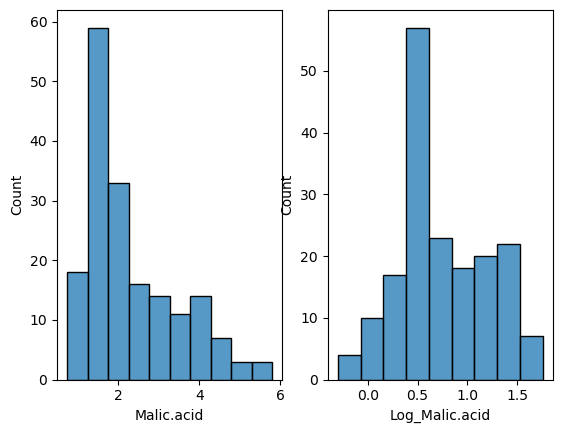

In [14]:
fig, ax = plt.subplots(1, 2)
sns.histplot(wines['Malic.acid'], ax = ax[0])
sns.histplot(wines['Log_Malic.acid'],  ax = ax[1])

<Axes: xlabel='Log_Mg', ylabel='Count'>

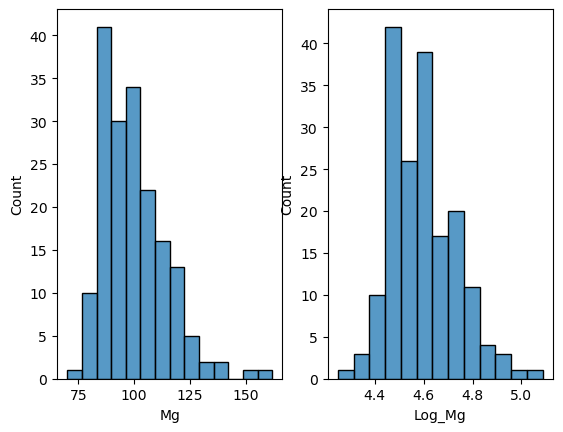

In [15]:
fig, ax2 = plt.subplots(1, 2)
sns.histplot(wines['Mg'], ax = ax2[0])
sns.histplot(wines['Log_Mg'], ax = ax2[1])

### Think!
Have the distributions changed between the original and the log-transformed data?

Put your answer below: </br>
Yes the transformation has affected the shapes of the distribution

<b>With this improvement, we will use the transformed variables 'Log_Malic.acid' and 'Log_Mg' as part of the clustering variables. Let's drop the original variables.<br> <b>

In [23]:
# Let's use another variable wines_trans hold the `DataFrame` after tranformation
wines_trans = wines.drop(['Malic.acid', 'Mg'], axis = 1)
wines_trans.head()

,Alcohol,Ash,Acl,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline,Log_Malic.acid,Log_Mg
0,14.23,2.43,15.6,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0.536493,4.844187
1,13.20,2.14,11.2,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0.576613,4.605170
2,13.16,2.67,18.6,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0.858662,4.615121
3,14.37,2.50,16.8,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0.667829,4.727388
4,13.24,2.87,21.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0.951658,4.770685


#### 2.2 Standardization - Scaling the columns using Z-score method

**Check this API Doc :** <br>
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

To use Min-Max method for standardization, use Scikit-Learn MinMaxScaler instead. 

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
# scales data as z = (x - u) / s

# create a StandardScaler object
scaler = StandardScaler()

# fit a scaler using the wines data by calling the fit() function 
scaler.fit(wines_trans)

,copy,True
,with_mean,True
,with_std,True


In [27]:
scaler.get_params()

{'copy': True, 'with_mean': True, 'with_std': True}

#### a. Print the `mean` and `variance` attributes from the `scaler` object after calling `fit()`

In [29]:
# Solution - Number of means = Number of variables
scaler.mean_

array([1.30006180e+01, 2.36651685e+00, 1.94949438e+01, 2.29511236e+00,
       2.02926966e+00, 3.61853933e-01, 1.59089888e+00, 5.05808988e+00,
       9.57449438e-01, 2.61168539e+00, 7.46893258e+02, 7.45051664e-01,
       4.59304201e+00])

In [31]:
# Solution
scaler.var_

array([6.55359730e-01, 7.48418003e-02, 1.10900306e+01, 3.89489032e-01,
       9.92113512e-01, 1.54016191e-02, 3.25754248e-01, 5.34425585e+00,
       5.19514497e-02, 5.01254463e-01, 9.86096010e+04, 2.01607859e-01,
       1.85621961e-02])

The `fit` function computes the mean and standard deviation of the original data but does not scale the data until `transform()` is applied.


#### b. Tranform the wines data using the `transform()` function

The function `transform()` is `Scikit-Learn` way of performing the function. Do not be confused with the Data Transformation which we did in Section 2.2.

#### Call the `transform()` function and save the result in `wines_scaled_np`.

In [34]:
# Get the transformed (standardized) variables by calling the transform function 
wines_scaled_np = scaler.transform(wines_trans)

In [35]:
wines_scaled_np

array([[ 1.51861254,  0.23205254, -1.16959318, ...,  1.01300893,
        -0.46448718,  1.84335927],
       [ 0.24628963, -0.82799632, -2.49084714, ...,  0.96524152,
        -0.3751346 ,  0.0890186 ],
       [ 0.19687903,  1.10933436, -0.2687382 , ...,  1.39514818,
         0.25302455,  0.16205222],
       ...,
       [ 0.33275817, -0.38935541,  0.15166079, ...,  0.28057537,
         1.57881801,  1.42722574],
       [ 0.20923168,  0.01273209,  0.15166079, ...,  0.29649784,
         0.46013964,  1.42722574],
       [ 1.39508604,  1.36520822,  1.50294326, ..., -0.59516041,
         1.48312691, -0.21060743]], shape=(178, 13))

In [37]:
# What is the data type of scaled data returned by transform()?
type(wines_scaled_np)

numpy.ndarray

#### Let's create a DataFrame `wines_prepared` using `wines_scaled_np` as input and columns same as `wines`

In [38]:
# Prepare a DataFrame with the transformed data, use the same column names as the original dataframe
wines_prepared = pd.DataFrame(wines_scaled_np, columns= wines_trans.columns)

In [39]:
wines_prepared.head()

,Alcohol,Ash,Acl,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline,Log_Malic.acid,Log_Mg
0,1.518613,0.232053,-1.169593,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009,-0.464487,1.843359
1,0.246290,-0.827996,-2.490847,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242,-0.375135,0.089019
2,0.196879,1.109334,-0.268738,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148,0.253025,0.162052
3,1.691550,0.487926,-0.809251,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574,-0.171984,0.986074
4,0.295700,1.840403,0.451946,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874,0.460140,1.303865


In [40]:
wines_prepared.describe()

,Alcohol,Ash,Acl,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline,Log_Malic.acid,Log_Mg
count,1.780000e+02,1.780000e+02,1.780000e+02,178.000000,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02
mean,-8.382808e-16,-8.370333e-16,-3.991813e-17,0.000000,-3.991813e-16,3.592632e-16,-1.197544e-16,2.494883e-17,1.995907e-16,3.193450e-16,-1.596725e-16,-3.991813e-17,5.987720e-16
std,1.002821e+00,1.002821e+00,1.002821e+00,1.002821,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00
min,-2.434235e+00,-3.679162e+00,-2.671018e+00,-2.107246,-1.695971e+00,-1.868234e+00,-2.069034e+00,-1.634288e+00,-2.094732e+00,-1.895054e+00,-1.493188e+00,-2.329931e+00,-2.528911e+00
25%,-7.882448e-01,-5.721225e-01,-6.891372e-01,-0.885468,-8.275393e-01,-7.401412e-01,-5.972835e-01,-7.951025e-01,-7.675624e-01,-9.522483e-01,-7.846378e-01,-6.090997e-01,-8.492551e-01
50%,6.099988e-02,-2.382132e-02,1.518295e-03,0.095960,1.061497e-01,-1.760948e-01,-6.289785e-02,-1.592246e-01,3.312687e-02,2.377348e-01,-2.337204e-01,-2.712520e-01,-5.926561e-02
75%,8.361286e-01,6.981085e-01,6.020883e-01,0.808997,8.490851e-01,6.095413e-01,6.291754e-01,4.939560e-01,7.131644e-01,7.885875e-01,7.582494e-01,8.477374e-01,5.856208e-01
max,2.259772e+00,3.156325e+00,3.154511e+00,2.539515,3.062832e+00,2.402403e+00,3.485073e+00,3.435432e+00,3.301694e+00,1.960915e+00,2.971473e+00,2.255655e+00,3.629939e+00


### Think!
- What is the mean and std dev of each variable?
- Why do we standardize (scale) all the variables?
- When we do transformation, do we tranform all the variables? 

Put your answer below: </br>
For all the variables, mean = 0 and std = 1

**How do the histograms look after transformation and scaling?**

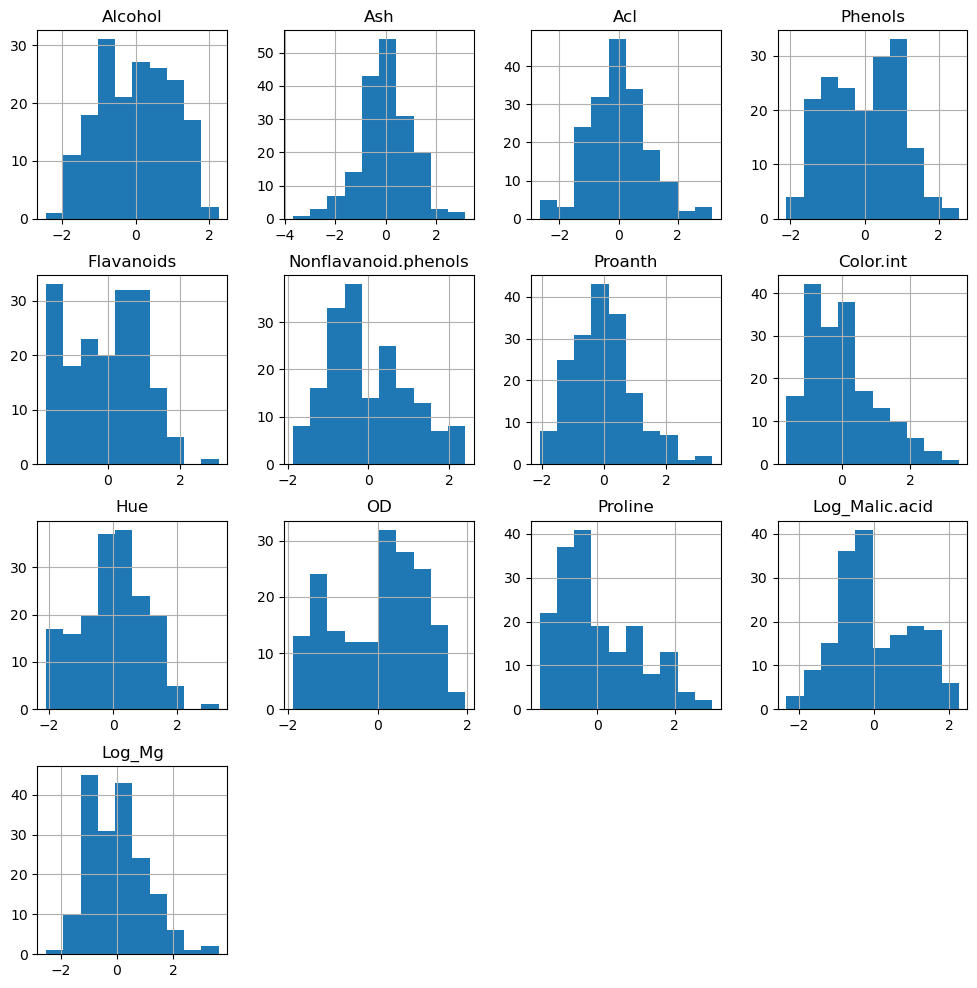

In [41]:
wines_prepared.hist(figsize= (12,12))
plt.show()

### Think!
Did standardization (scaling) change the distributions?


Put your answer below: </br>
When we standardise, the shape of the distributions typically do not change

Bin sizes might affect the shape of the distributions, but if you use thinner bins, most likely the shapes will be very similar

### 3. Modeling using KMeans

#### 3.1 Finding value of k
**We will use the transformed and scaled data in `wines_prepared` for clustering.** <br>
**Run KMeans clustering for k = 1 to 7, using random_state = 99**<br>
**Plot the Elbow curve for k = (1, 7) and find the suitable k.**

In [42]:
from sklearn.cluster import KMeans

In [ ]:
# Add a for loop to compute the SSE for k values from 1 to 7.
# We include k=1 to compute the total sum of squares (no clustering).

In [43]:
SSE = []

for i in range(1,8):
    model_i = KMeans(n_clusters = i, random_state=99)
    model_i.fit(wines_prepared)
    SSE.append(model_i.inertia_)

C:\Users\Durga\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Durga\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Durga\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Durga\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [44]:
SSE

[2314.0,
 1659.787650077193,
 1272.4666709733042,
 1172.422902577435,
 1137.599342650021,
 1097.383387770305,
 1012.2044655048054]

Text(0, 0.5, 'SSE')

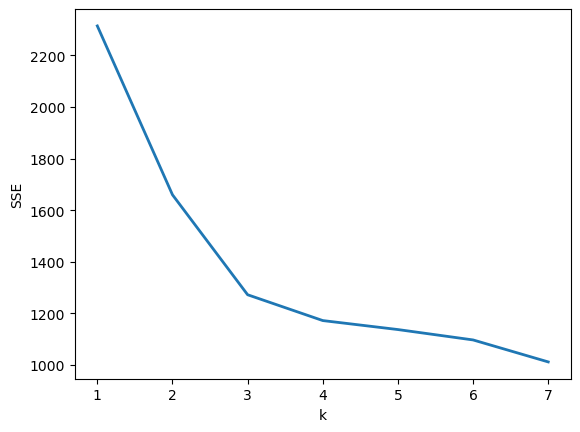

In [48]:
# Plot the elbow curve
# k = (range(1,8))

plt.plot(range(1,8), SSE, linewidth=2.0)
plt.xlabel('k')
plt.ylabel('SSE')

# Other cosmetic settings
#plt.title('Elbow curve')
#plt.xlabel('k')
#plt.ylabel('SSE')
#plt.grid(True)
#plt.show()

#### 3.2 Perform clustering with selected k


**Perform clustering with n_clusters = 3, random_state = 99 :**

In [50]:
# Write your code below

model = KMeans(n_clusters= 3, random_state= 99)
model.fit(wines_prepared)

C:\Users\Durga\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,99
,copy_x,True
,algorithm,'lloyd'


In [52]:
# print the attributes inertia_, n_iter, cluster_centers_ of the obtained model

# uncomment these codes below after you have the model
print("Attributes of the clustering solution for k=3:")
print("SSE :", round(model.inertia_, 1))
print("Num of iterations :" , model.n_iter_)
print("\nCluster centers :" , model.cluster_centers_)

Attributes of the clustering solution for k=3:
SSE : 1272.5
Num of iterations : 4

Cluster centers : [[-0.91878983 -0.50621556  0.15575559 -0.0815105   0.01107713 -0.01249687
   0.0316085  -0.88371381  0.45630563  0.24479697 -0.75674934 -0.4871574
  -0.52279809]
 [ 0.83523208  0.36470604 -0.61019129  0.88523736  0.97781956 -0.56208965
   0.58028658  0.17106348  0.47398365  0.77924711  1.12518529 -0.20924313
   0.60221578]
 [ 0.17711479  0.21596904  0.55103983 -0.99010047 -1.22711807  0.71348704
  -0.76127859  0.95438352 -1.19006316 -1.28939841 -0.39632062  0.90250924
  -0.05665409]]


### Think!
- Did the clustering solution converge?
- State why. 

Put your answer below:

    - 

### 4. Cluster Evaluation and Profiling (Interpretation)

#### 4.1 Cluster Evaluation

When k = 1, all data points belong to a single cluster, so the inertia equals the total sum of squares (total variance). 
When k > 1, clustering reduces the within-cluster sum of squares by grouping similar points together. 
The reduction in SSE represents the amount of variance explained by the clustering.

Clustering introduces additional structure by dividing the data into multiple groups. 
The ratio $\frac{𝒃𝒆𝒕𝒘𝒆𝒆𝒏SS}{𝑻𝑺𝑺}$ gives the proportion of the total variance explained by the clustering.
Multiplying this ratio by 100 yields the percentage of variance explained relative to placing all points in a single cluster.

In [ ]:
# Uncomment these codes below after you have the model
#between_ss = SSE[0]- model.inertia_
#improvement = (between_ss / SSE[0])*100
#print('The improvement of SSE due to clustering (k=3) is: ' + str(round(improvement,2)) + '%')

In [ ]:
# Evaluate if the clusters formed are well distributed
# Add the `cluster` column in the original wines DataFrame
 
# uncomment these codes below after you have the model
#wines['cluster'] = model.labels_
#wines['cluster'].value_counts()

The observations are relatively well distributed across the clusters.

#### 4.2 Cluster Profiling (Interpretation)

**Plot the cluster centroids as given by the model. This helps us check the variable properties per cluster :**

In [ ]:
# uncomment these codes below after you have the model
#model.cluster_centers_

In [ ]:
# create a DataFrame of cluster centers. Note that row 0 corresponds to cluster label = 0

#clust_means = pd.DataFrame(model.cluster_centers_, columns=wines_prepared.columns)

In [ ]:
#clust_means

It is not trivial to analyse the profile of the clusters with those 13 variables. So we suggest to draw a heatmap.

##### Seaborn heatmap for profiling using centroid method

In [ ]:
import seaborn as sns

In [ ]:
#sns.heatmap(clust_means.T,  linewidths=.5, cmap="YlGnBu")

**Cluster interpretation**<br>
The above cluster composition indicates that some cultivars have specific chemical signatures. 

For instance, based on the centroids: 
- <b>Cluster 0</b> is characterized by low alcohol, color intensity, and proline levels. <br />
The other chemical components are below average or near the average.

- <b>Cluster 1</b> is characterized by high values in the alcohol, phenols, flavanoids and proline levels. The wines have also reasonable high proanthocyanins, hue, magnesium and OD levels.

- <b>Cluster 2</b> has very high Malic Acid, nonflavanoid phenols, strong color intensity and Alcalinity. <br />
The wines of this cluster have above average levels of Magnesium, Ash and Alcohol. 


Note: the cluster numbers may differ on your laptop.

### 5. Weighting


We will illustrate the use of weighting on a selected variable. 
<br />Suppose a customer wants to buy a wine with a higher level of Magnesium. We want to select the right wine for that customer. 
So we are going to add a weight to the variable representing Magnesium.

In [ ]:
# Create a new dataframe
wines_weighted = pd.DataFrame(wines_prepared, columns=wines_prepared.columns)

In [ ]:
wgt = 4
wines_weighted['Log_Mg_Wt'] = wines_weighted['Log_Mg']*wgt
wines_weighted.head()

In [ ]:
# Drop Log_Mg variable
wines_weighted = wines_weighted.drop(['Log_Mg'], axis = 1)

In [ ]:
# Run KMeans
model_wt = KMeans(n_clusters= 3, random_state= 99)
model_wt.fit(wines_weighted)

In [ ]:
# Visualize the clusters
clust_means_wt = pd.DataFrame(model_wt.cluster_centers_, columns=wines_weighted.columns)
sns.heatmap(clust_means_wt.T,  linewidths=.5, cmap="YlGnBu")

### Think!
What do you observe about the formation of the clusters?

Put your answer below:

    - 

In this particular example, the value of `wgt` has been arbitrarily set. <br >
One may want to fine tune that value to also consider the other properties of wines.

### 6. Models Comparison

Perhaps, you might wonder - what is the effect if we do not transform or standardize the data?
<br>Let's run k-means clustering based on original data, i.e., wines. 

In [ ]:
# Using k = 3
model2 = KMeans(n_clusters= 3, random_state= 99)
model2.fit(wines)

Let's look at the profile of the clusters.

In [ ]:
clust_means2 = pd.DataFrame(model2.cluster_centers_, columns=wines.columns)

In [ ]:
sns.heatmap(clust_means2.T,  linewidths=.5, cmap="YlGnBu")

### Think!
What do you notice about the clusters features?

Put your answer below:

    - 

This is the reason why we need to <b>standardize</b> the variables when one or more variables have a range of values much higher than the rest of the variables.

### Refresh Memory!
Let's refresh our memory: 

What is the mean value of `Proline` in the cluster with 62 observations?<br />
<u>Hint</u>: Do you remember the `groupby` function?

In [ ]:
# Write your code below

